In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])

from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
DataClass = STL_2D_Kernel_Torch
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)


import torch

Parent directory added to sys.path: .../STL_4
Dataset dirctory used: .../STL_4/data/test
Working on device: cuda


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

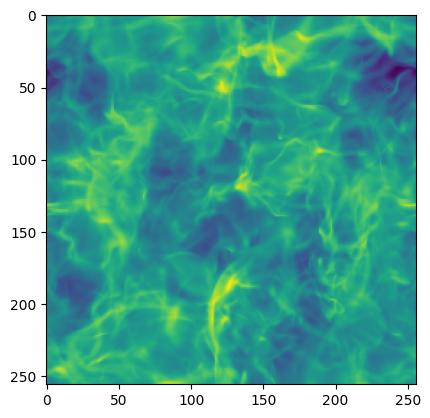

In [3]:
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:,None,:,:]
data = DataClass(im[0,0], pbc=True)
plt.imshow(data.array.cpu().numpy())

In [6]:
wavelet_op = data.get_wavelet_op()
mean = wavelet_op.mean(data=data)#, wavelet_convolved=False)
print("Mean of stl_data_type:", mean)

Mean of stl_data_type: tensor(20.3195, device='cuda:0', dtype=torch.float64)


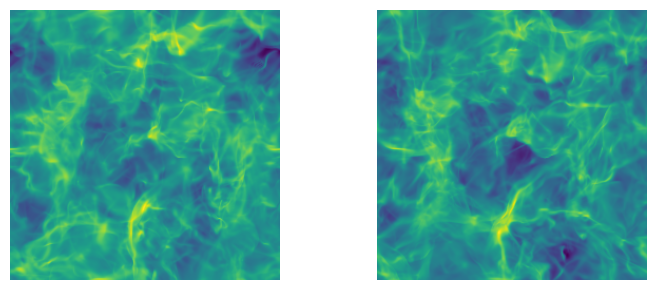

Covariance = tensor(0.0247, device='cuda:0', dtype=torch.float64)



In [8]:
# Prepare centralized data for covariance tests
stl_data0 = DataClass(im[0,0]-im[0,0].mean())
stl_data1 = DataClass(im[1,0]-im[1,0].mean())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes = axes.ravel()
axes[0].imshow(stl_data0.array.cpu().numpy())
axes[0].axis('off')
axes[1].imshow(stl_data1.array.cpu().numpy())
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Test of Cov
cov = wavelet_op.cov(stl_data0, stl_data1)#, wavelet_convolved=False)
print("Covariance = " + str(cov))
print()

In [19]:
target = im[0,0,:,:]
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None
seed = 0

In [20]:
print(np.shape(target.array))

torch.Size([256, 256])


# nbatch = 1

In [21]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=500,
        lr=1,
        history_size=50,
        print_iter=50,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (1, 1, 256, 256)
Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 50, loss = 1.050904e+00
[LBFGS] inner iter 100, loss = 7.080182e-01
[LBFGS] inner iter 150, loss = 6.181049e-01
[LBFGS] inner iter 200, loss = 5.690698e-01
[LBFGS] inner iter 250, loss = 5.567389e-01
[LBFGS] inner iter 300, loss = 5.501023e-01
[LBFGS] inner iter 350, loss = 5.457477e-01
[LBFGS] inner iter 400, loss = 5.405810e-01
[LBFGS] inner iter 450, loss = 5.356298e-01
[LBFGS] inner iter 500, loss = 5.336524e-01
515 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 20.717 s


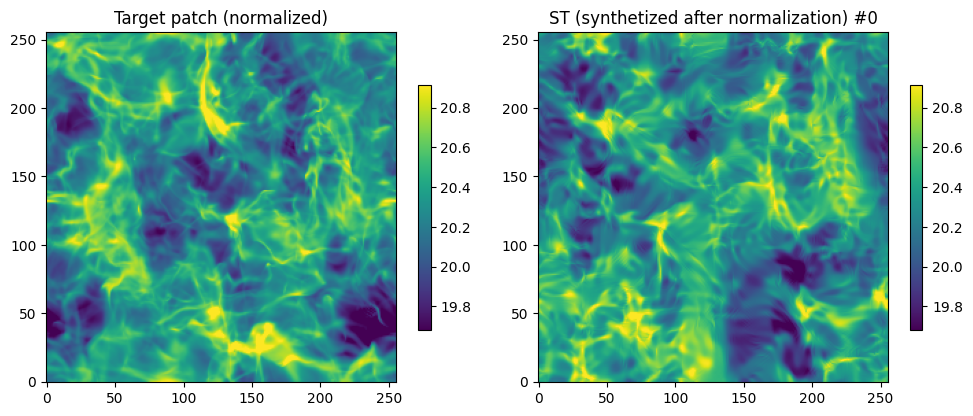

20.319510503220542
0.25344100340422065
0.2532717030966275


In [26]:
plt.figure(figsize=(10,4))
patch = im[0,0,:,:]

vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
#plt.imshow(np.fft.fftshift(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.imshow(im[0,0,:,:], origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch (normalized)")

plt.subplot(1,2,2)
plt.imshow(u1.cpu().numpy(), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST (synthetized after normalization) #0")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))

# nbatch = 10

In [27]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=10,
        max_iter=500,
        lr=1,
        history_size=50,
        print_iter=50,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (10, 1, 256, 256)
Replacing existing S2_ref_sqrt_chan_diag in ST_Op
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 50, loss = 8.088813e-01
[LBFGS] inner iter 100, loss = 4.227660e-01
[LBFGS] inner iter 150, loss = 3.838985e-01
[LBFGS] inner iter 200, loss = 3.727887e-01
[LBFGS] inner iter 250, loss = 3.681357e-01
[LBFGS] inner iter 300, loss = 3.653366e-01
[LBFGS] inner iter 350, loss = 3.630567e-01
[LBFGS] inner iter 400, loss = 3.615177e-01
[LBFGS] inner iter 450, loss = 3.606258e-01
[LBFGS] inner iter 500, loss = 3.600348e-01
516 iterations of synthesis done with nbatch=10 and 3970 ST coefficients
Execution time: 55.181 s


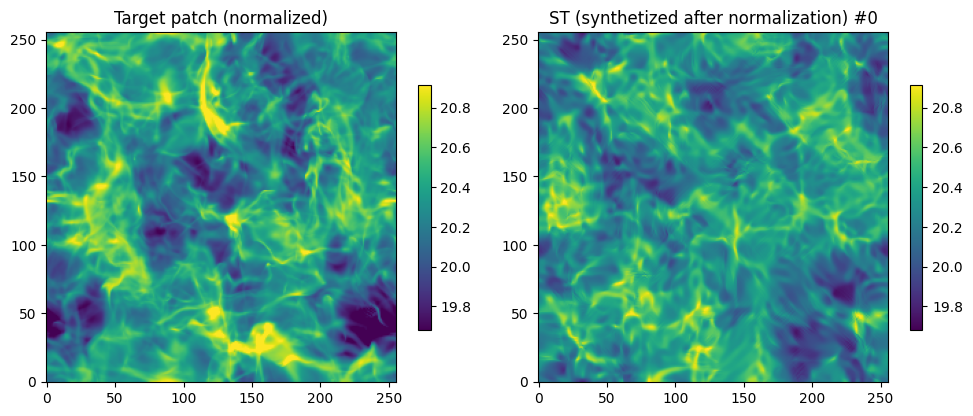

20.319511094440273
0.25298933808306184
0.2532717030966275


In [28]:
plt.figure(figsize=(10,4))
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
#plt.imshow(np.fft.fftshift(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.imshow(patch, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch (normalized)")

plt.subplot(1,2,2)
plt.imshow(u1[0].cpu().numpy(), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST (synthetized after normalization) #0")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))

# normalization

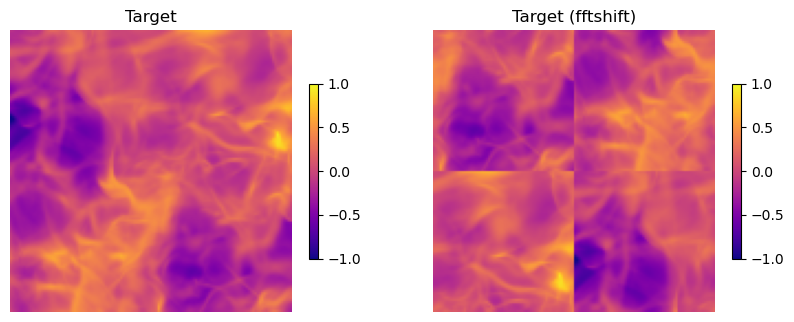

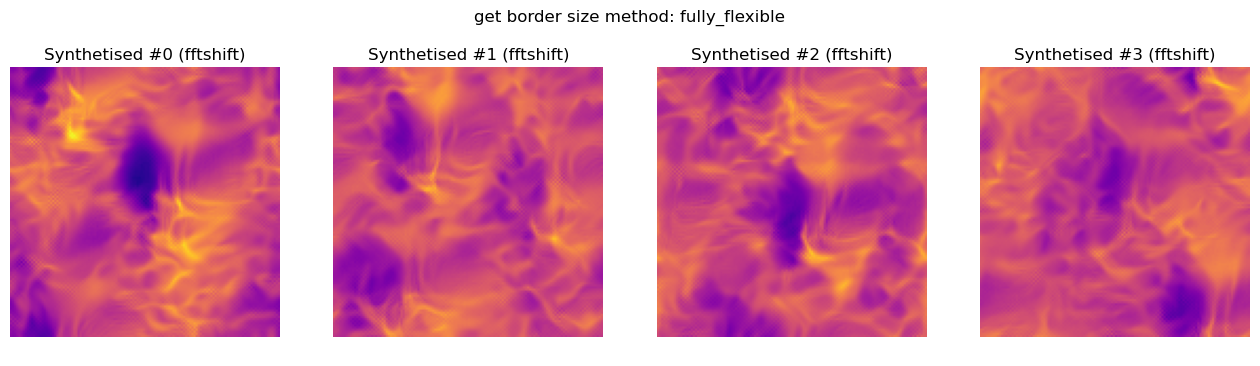

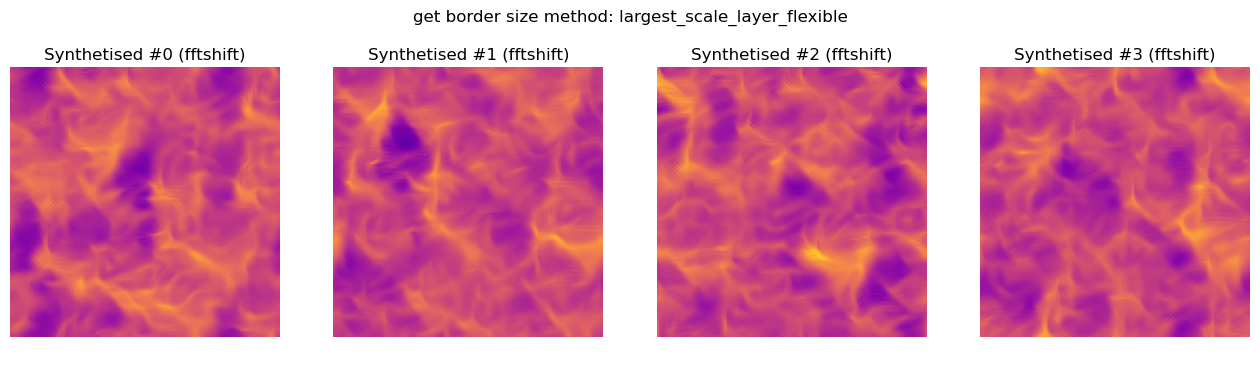

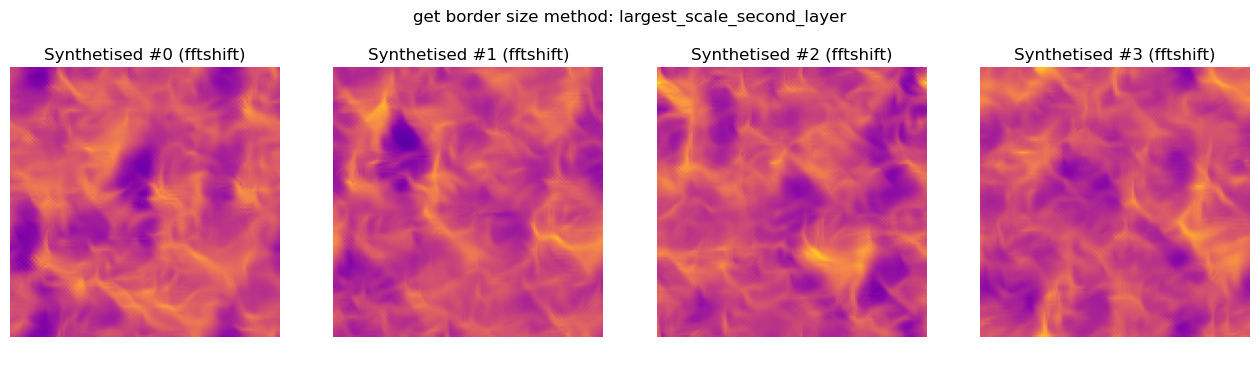

In [99]:
amp = 1

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.imshow(im[0,0,:128,:128]-np.nanmean(im[0,0,:128,:128]), cmap='plasma', vmin=-amp, vmax=amp)
plt.colorbar(shrink=0.5)
plt.axis('off')
plt.title('Target')
plt.subplot(2,2,2)
plt.imshow(np.fft.fftshift(im[0,0,:128,:128]-np.nanmean(im[0,0,:128,:128])), cmap='plasma', vmin=-amp, vmax=amp)
plt.colorbar(shrink=0.5)
plt.axis('off')
plt.title('Target (fftshift)')

for method_name, (u, _) in synthesis_target_npbc_results.items():

    plt.figure(figsize=(16,4))
    plt.title('get border size method: %s\n'%method_name)
    plt.axis('off')
    for k in range(4):
        plt.subplot(1,4,1+k)
        plt.imshow(np.fft.fftshift(u[k].cpu().numpy()), cmap='plasma', vmin=-amp, vmax=amp)
        #plt.colorbar(shrink=0.5)
        plt.axis('off')
        plt.title('Synthetised #%d (fftshift)'%(k))

In [100]:
synthesis_target_running_npbc_results = {}

target = DataClass(im[0,0,:128,:128], pbc=False)

for method_name, get_crop_border_size_method in zip(['fully_flexible', 
                                                     'largest_scale_layer_flexible', 
                                                     'largest_scale_second_layer'],
                                                    [WO._get_crop_border_size_fully_flexible,
                                                     WO._get_crop_border_size_largest_scale_layer_flexible,
                                                     WO._get_crop_border_size_largest_scale_second_layer]):
    print(method_name)
    J = 5 if method_name == 'fully_flexible' else 4

    st_op = target.get_ST_op(J=J, get_crop_border_size_method=get_crop_border_size_method)

    u, histo = optimize_scattering_LBFGS(
            target=target,
            st_op_target=st_op,
            st_op_running=st_op,
            pbc_running=False,
            nbatch=4,
            max_iter=150,
            lr=1.0,
            history_size=50,
            print_iter=10,
            verbose=True,
            seed=seed,
        )

    synthesis_target_running_npbc_results[method_name] = (u, histo)

fully_flexible
Running synthesis on device mps:0 dtype torch.float32
Initial shape for u: (4, 1, 128, 128)
Warning! Data with shape (8, 8) too small to be cropped with border 4. Using border=3 instead.
Synthesis on 2520 ST coefficients
[LBFGS] inner iter 10, loss = 3.095016e+04
[LBFGS] inner iter 20, loss = 1.188747e+01
[LBFGS] inner iter 30, loss = 2.049555e+00
[LBFGS] inner iter 40, loss = 8.383077e-01
[LBFGS] inner iter 50, loss = 4.306901e-01
[LBFGS] inner iter 60, loss = 2.613508e-01
[LBFGS] inner iter 70, loss = 1.795252e-01
[LBFGS] inner iter 80, loss = 1.310720e-01
[LBFGS] inner iter 90, loss = 1.028096e-01
[LBFGS] inner iter 100, loss = 8.329745e-02
[LBFGS] inner iter 110, loss = 6.983855e-02
[LBFGS] inner iter 120, loss = 5.895906e-02
[LBFGS] inner iter 130, loss = 5.112383e-02
[LBFGS] inner iter 140, loss = 4.407055e-02
[LBFGS] inner iter 150, loss = 3.865776e-02
156 iterations of synthesis done with nbatch=4 and 2520 ST coefficients
Execution time: 42.263 s
largest_scale_la

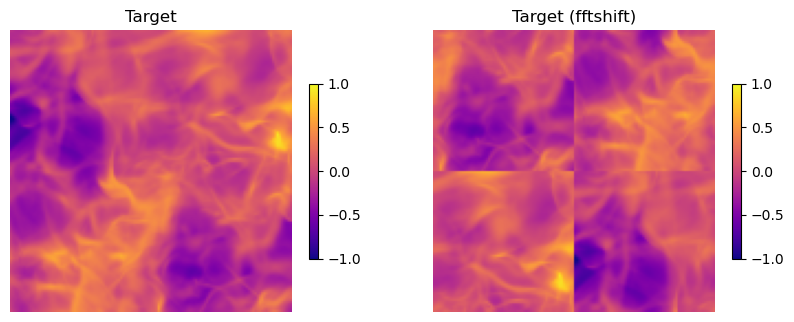

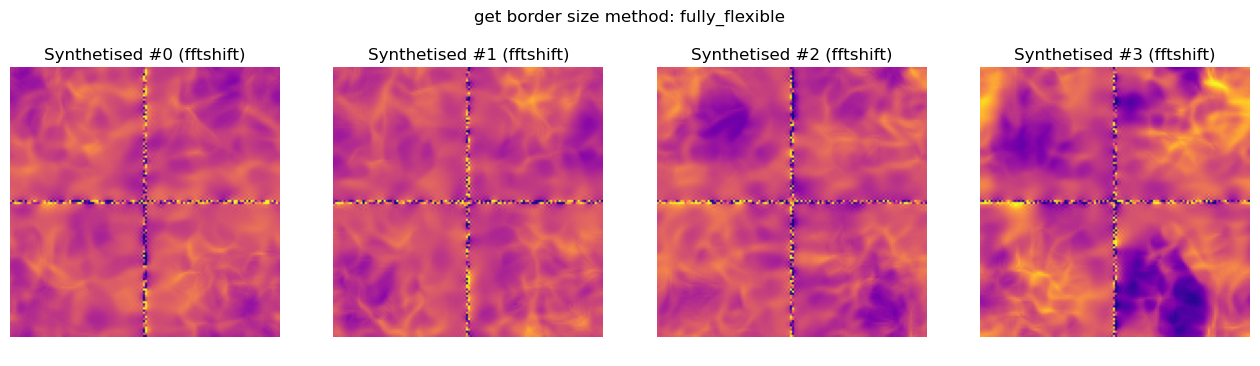

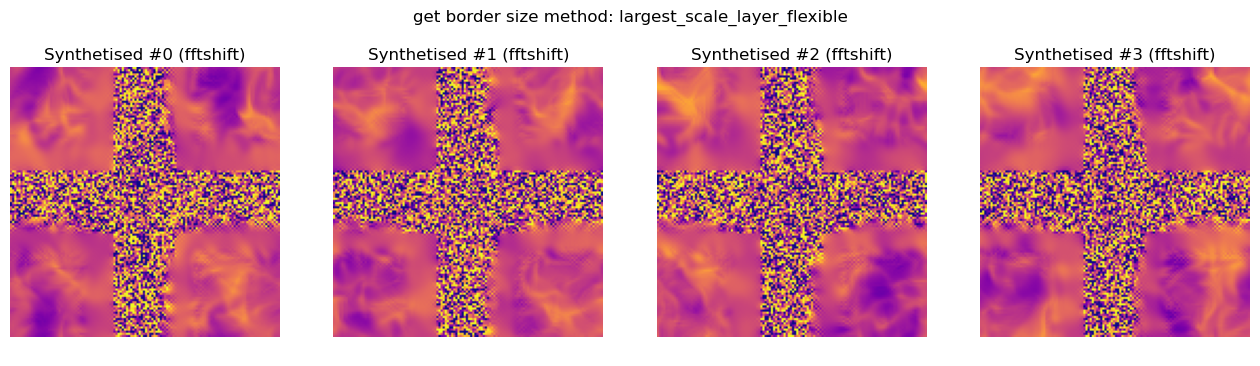

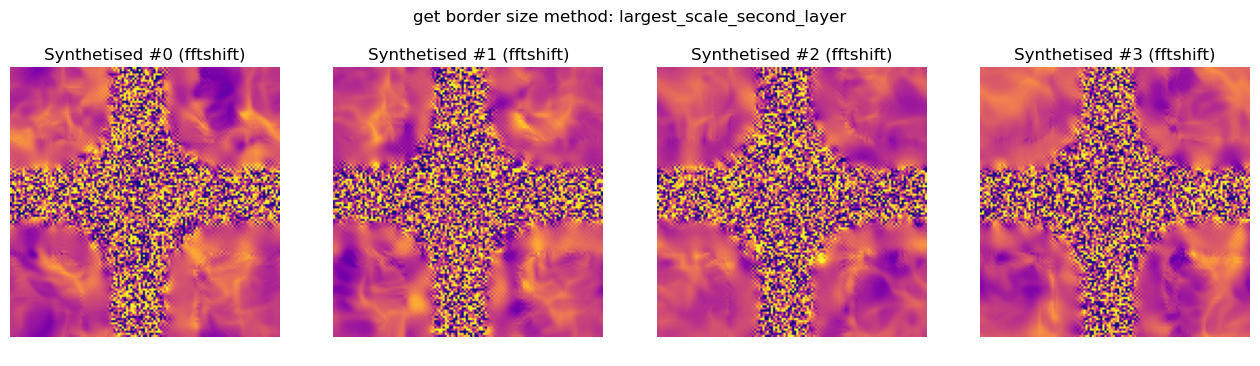

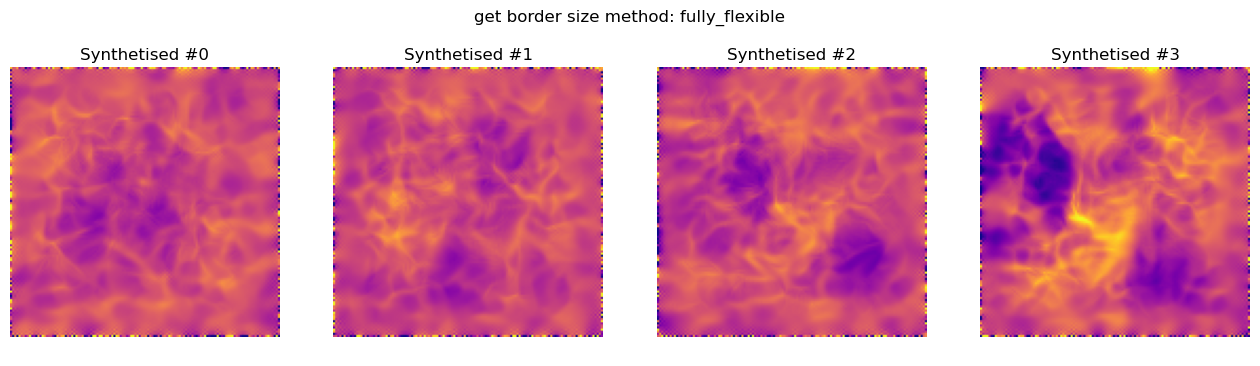

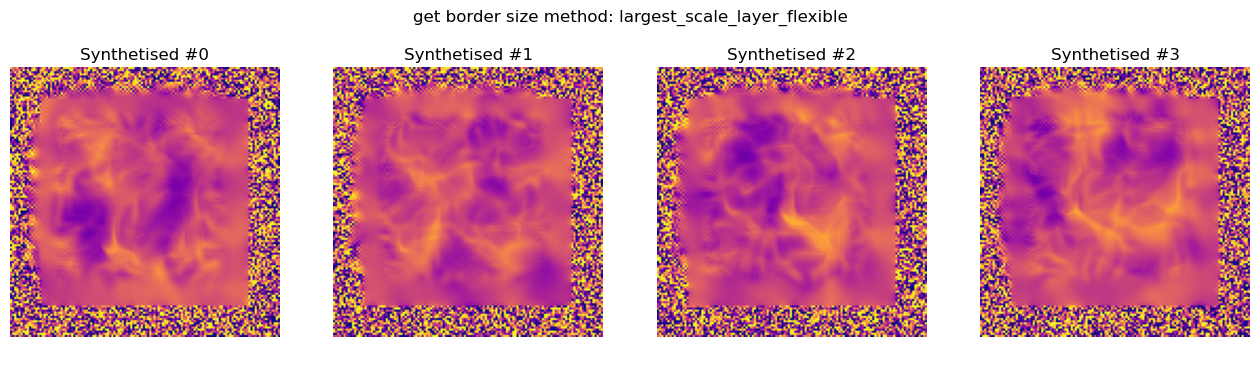

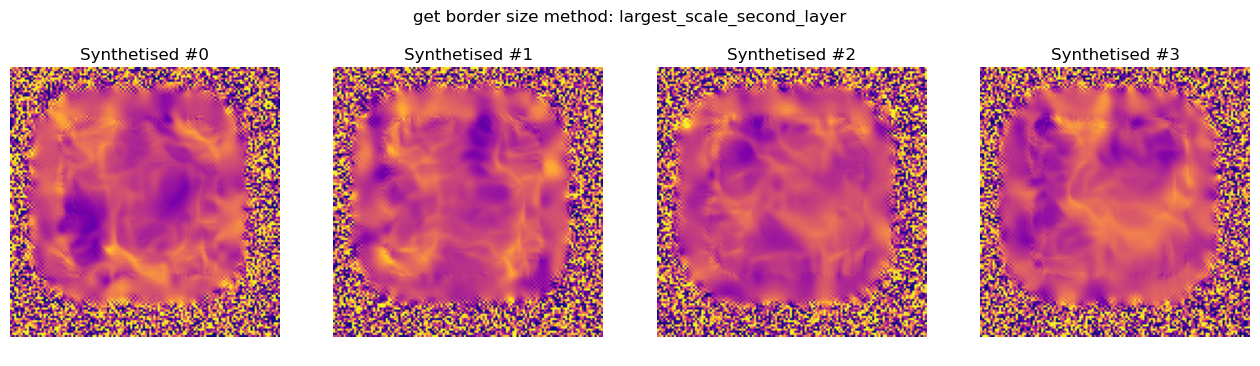

In [101]:
amp = 1

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.imshow(im[0,0,:128,:128]-np.nanmean(im[0,0,:128,:128]), cmap='plasma', vmin=-amp, vmax=amp)
plt.colorbar(shrink=0.5)
plt.axis('off')
plt.title('Target')
plt.subplot(2,2,2)
plt.imshow(np.fft.fftshift(im[0,0,:128,:128]-np.nanmean(im[0,0,:128,:128])), cmap='plasma', vmin=-amp, vmax=amp)
plt.colorbar(shrink=0.5)
plt.axis('off')
plt.title('Target (fftshift)')

for method_name, (u, _) in synthesis_target_running_npbc_results.items():
    plt.figure(figsize=(16,4))
    plt.title('get border size method: %s\n'%method_name)
    plt.axis('off')
    for k in range(4):
        plt.subplot(1,4,1+k)
        plt.imshow(np.fft.fftshift(u[k].cpu().numpy()), cmap='plasma', vmin=-amp, vmax=amp)
        #plt.colorbar(shrink=0.5)
        plt.axis('off')
        plt.title('Synthetised #%d (fftshift)'%(k))

for method_name, (u, _) in synthesis_target_running_npbc_results.items():
    plt.figure(figsize=(16,4))
    plt.title('get border size method: %s\n'%method_name)
    plt.axis('off')
    for k in range(4):
        plt.subplot(1,4,1+k)
        plt.imshow(u[k].cpu().numpy(), cmap='plasma', vmin=-amp, vmax=amp)
        #plt.colorbar(shrink=0.5)
        plt.axis('off')
        plt.title('Synthetised #%d'%(k))